# 05 — GARCH(1,1)-t and EGARCH(1,1)-t Models

**What:** Fit three volatility models — a constant-volatility baseline, GARCH(1,1)-t, and EGARCH(1,1)-t — compare them formally on AIC/BIC, diagnose the winning model's residuals, and log all three runs to MLflow.

**Why:** Notebooks 03 and 04 proved the Black-Scholes assumptions break down. This notebook builds something better. The argument is: we showed the baseline is wrong → we fit two models that address those failures → we let the data choose between them formally. Every parameter in the output connects back to what the tests found.

**Outline:**

0. Setup
1. Parameter Reference
2. Baseline — Constant Volatility
3. GARCH(1,1)-t Model
4. EGARCH(1,1)-t Model
5. Model Comparison — AIC/BIC
6. Residual Diagnostics
7. MLflow Logging
8. Conclusion


---
---
## 0. Setup


In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from scipy.stats import norm, probplot, t as student_t
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
import mlflow
ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

from src.models.garch import VolatilityModel
from src.data.describe import compute_returns

# --- load data ---
mxn     = pd.read_csv(ROOT / 'data/raw/mxn_usd.csv', index_col='Date', parse_dates=True)
returns = compute_returns(mxn['MXN_USD'])

print(f'Return series: {returns.index[0].date()} → {returns.index[-1].date()}')
print(f'Observations : {len(returns):,}')



Return series: 2000-01-04 → 2026-03-06
Observations : 6,588


---
---
## Parameter Reference

Before fitting any model it helps to have the full parameter vocabulary
in one place. Every quantity printed in sections 2–4 is defined here.

---

### Baseline — Constant Volatility

$$r_t = \mu + \epsilon_t, \qquad \epsilon_t \sim \mathcal{N}(0, \sigma^2)$$

| Parameter | Symbol | Interpretation |
|-----------|--------|----------------|
| Mean | $\mu$ | Unconditional mean return — assumed constant |
| Volatility | $\sigma$ | Constant standard deviation — no dynamics, no memory |

The baseline has no concept of time-varying risk. Every day looks the same
to it regardless of whether we are in a crisis or a calm period.

---

### GARCH(1,1)-t

$$\sigma_t^2 = \omega + \alpha \epsilon_{t-1}^2 + \beta \sigma_{t-1}^2, \qquad z_t \sim t_\nu(0,1)$$

| Parameter | Symbol | Interpretation |
|-----------|--------|----------------|
| Mean | $\mu$ | Conditional mean return |
| Variance floor | $\omega$ | Long-run variance intercept — must be $> 0$ |
| ARCH term | $\alpha$ | Sensitivity to last period's shock $\epsilon_{t-1}^2$ — how much a new shock feeds into today's variance |
| GARCH term | $\beta$ | Variance persistence — how much of yesterday's variance $\sigma_{t-1}^2$ carries into today |
| Tail shape | $\nu$ | Student-t degrees of freedom — controls tail heaviness. Lower $\nu$ means heavier tails. $\nu \to \infty$ recovers the normal distribution |
| Persistence | $\alpha + \beta$ | Fraction of a shock that survives to the next period. Close to 1 means slow decay |

**Half-life of a volatility shock:**

$$\text{Half-life} = \frac{\log(0.5)}{\log(\alpha + \beta)} \text{ trading days}$$

A persistence of $0.987$ gives a half-life of $\approx 53$ trading days —
a shock today is still half as strong after 53 days.

---

### EGARCH(1,1)-t

$$\log(\sigma_t^2) = \omega + \beta \log(\sigma_{t-1}^2) + \alpha\left(|z_{t-1}| - \mathbb{E}[|z_{t-1}|]\right) + \gamma z_{t-1}, \qquad z_t \sim t_\nu(0,1)$$

| Parameter | Symbol | Interpretation |
|-----------|--------|----------------|
| Mean | $\mu$ | Conditional mean return |
| Log-variance intercept | $\omega$ | Baseline level of $\log(\sigma_t^2)$ |
| Magnitude term | $\alpha$ | Sensitivity to the size of the shock $|z_{t-1}|$ — how much a large move in either direction increases variance |
| Asymmetry term | $\gamma$ | Sign sensitivity $\gamma > 0$ means positive shocks amplify variance more than negative shocks of equal size; $\gamma < 0$ means negative shocks amplify more (the classic equity leverage effect). The sign is an empirical finding, not an assumption |
| Persistence | $\beta$ | Fraction of today's $\log(\sigma_t^2)$ that carries into tomorrow — $\alpha$ and $\gamma$ only shape the shock response, they do not carry variance forward |
| Tail shape | $\nu$ | Same interpretatio

**Why persistence is $\beta$ alone in EGARCH (not $\alpha + \beta$):**

In GARCH, $\alpha$ measures how much a new shock feeds into variance *and*
contributes to how long it persists. In EGARCH, $\alpha$ only controls the
*magnitude response* to a shock — it does not feed into the
$\log(\sigma_{t-1}^2)$ carry-forward term. That carry-forward is governed
exclusively by $\beta$.

**Non-negativity by construction:**

Because EGARCH models $\log(\sigma_t^2)$, the conditional variance
$\sigma_t^2 = \exp(\log(\sigma_t^2))$ is always positive regardless of
parameter values. Standard GARCH requires the constraints
$\omega > 0$, $\alpha \geq 0$, $\beta \geq 0$ to guarantee this —
EGARCH does not.

---
---
## 2. Baseline — Constant Volatility

The baseline is the sample standard deviation used as a flat constant
volatility estimate. No dynamics, no model. Its only purpose is to give
a reference log-likelihood so $\Delta\text{AIC}$ and $\Delta\text{BIC}$
are meaningful numbers.

The baseline is fitted on **percent returns** (returns × 100) for
comparability with GARCH and EGARCH, which require the same scaling for
numerical stability.


In [2]:
r = returns * 100  # percent returns — same scale used by VolatilityModel internally
n = len(r)

log_lik_baseline  = norm.logpdf(r, loc=r.mean(), scale=r.std()).sum()
n_params_baseline = 2  # mu, sigma
aic_baseline      = -2 * log_lik_baseline + 2 * n_params_baseline
bic_baseline      = -2 * log_lik_baseline + n_params_baseline * np.log(n)

print(f'Baseline log-likelihood : {log_lik_baseline:,.2f}')
print(f'Baseline AIC            : {aic_baseline:,.2f}')
print(f'Baseline BIC            : {bic_baseline:,.2f}')


Baseline log-likelihood : -6,847.29
Baseline AIC            : 13,698.59
Baseline BIC            : 13,712.18


---
---
## 3. GARCH(1,1)-t Model

The GARCH(1,1) model specifies:

$$
r_t = \mu + \epsilon_t, \quad \epsilon_t = \sigma_t z_t \\
\sigma_t^2 = \omega + \alpha \epsilon_{t-1}^2 + \beta \sigma_{t-1}^2
$$

where $z_t$ are i.i.d. innovations. We choose Student-t innovations:

$$z_t \sim t_\nu(0, 1)$$

The log-likelihood for the GARCH-t model is:

$$\ell(\theta) = \sum_{t=1}^T \log f_t(r_t \mid \mathcal{F}_{t-1}; \theta)$$

where $f_t$ is the Student-t density scaled by $\sigma_t$, and
$\theta = (\mu, \omega, \alpha, \beta, \nu)$.

`VolatilityModel` handles the ×100 scaling internally — we pass raw decimal
returns and the class rescales before fitting.


In [3]:
garch = VolatilityModel('GARCH')
garch.fit(returns)

garch.to_frame()


,Parameter,Estimate,Std Error,t-stat
0,mu,-0.018893,0.006167,-3.063
1,omega,0.006755,0.001883,3.587
2,alpha[1],0.099927,0.015932,6.272
3,beta[1],0.887533,0.018106,49.019
4,nu,7.103405,0.602460,11.791
5,persistence,0.987460,NaN,NaN
6,AIC,11292.456700,NaN,NaN
7,BIC,11326.421700,NaN,NaN


---
---
## 4. EGARCH(1,1)-t Model

The standard GARCH(1,1) model treats positive and negative return shocks
symmetrically — a shock of magnitude $|\epsilon_{t-1}|$ produces the same
increase in conditional variance regardless of its sign. The Exponential GARCH
(EGARCH) model addresses this by modeling the *log* of the conditional variance:

$$
\log(\sigma_t^2) = \omega + \sum_{k=1}^{q} \beta_k \log(\sigma_{t-k}^2)
+ \sum_{k=1}^{p} \alpha_k \left(|z_{t-k}| - \mathbb{E}[|z_{t-k}|]\right)
+ \sum_{k=1}^{p} \gamma_k z_{t-k}
$$

where $z_t = \epsilon_t / \sigma_t$ are the standardized residuals. The key
difference from GARCH is the $\gamma_k z_{t-k}$ term:

- When $\gamma < 0$ (typical for **equity** markets — the leverage effect),
  negative shocks amplify volatility more than positive shocks of equal size.
- For **exchange rates** the sign of $\gamma$ is an empirical question.
  In notebook 03 we found positive skewness ($\hat{S} = +0.78$), suggesting
  large peso *appreciations* are slightly more extreme in the distribution
  than depreciations. Consistent with this, the fitted model yields
  $\hat{\gamma} > 0$ — positive shocks generate marginally larger volatility
  increases. This is the **opposite** of the standard equity leverage effect
  and is a genuine empirical finding specific to this currency pair.

**Why EGARCH in addition to GARCH-$t$?**

- **Asymmetry:** $\gamma$ quantifies the directional response to shocks —
  something GARCH cannot capture by construction.
- **Non-negativity by construction:** Because EGARCH models $\log(\sigma_t^2)$,
  the conditional variance is always positive without imposing parameter
  constraints ($\omega > 0$, $\alpha \geq 0$, $\beta \geq 0$ in standard GARCH).


In [4]:
egarch = VolatilityModel('EGARCH')
egarch.fit(returns)

egarch.to_frame()


,Parameter,Estimate,Std Error,t-stat
0,mu,-0.009042,0.006203,-1.458
1,omega,-0.020032,0.006306,-3.176
2,alpha[1],0.170618,0.026197,6.513
3,gamma[1],0.072322,0.010010,7.225
4,beta[1],0.978240,0.005891,166.064
5,nu,7.281522,0.644807,11.293
6,persistence,0.978240,NaN,NaN
7,AIC,11245.724800,NaN,NaN
8,BIC,11286.482800,NaN,NaN


---
---
## 5. Model Comparison — AIC/BIC

We compare all three models on AIC and BIC. Both penalize log-likelihood by
model complexity; BIC applies a stricter penalty ($\log n$ vs $2$) and is
preferred for large samples. Lower is better.


In [5]:
g = garch.summary()
e = egarch.summary()

comparison = pd.DataFrame({
    'Model'         : ['Baseline (constant σ)', 'GARCH(1,1)-t', 'EGARCH(1,1)-t'],
    'Parameters'    : [2, 5, 6],
    'Log-Likelihood': [round(log_lik_baseline, 2),
                       round(g['log_likelihood'], 2),
                       round(e['log_likelihood'], 2)],
    'AIC'           : [round(aic_baseline, 2), round(g['aic'], 2), round(e['aic'], 2)],
    'BIC'           : [round(bic_baseline, 2), round(g['bic'], 2), round(e['bic'], 2)],
})

comparison['ΔAIC'] = (comparison['AIC'] - comparison['AIC'].iloc[0]).round(2)
comparison['ΔBIC'] = (comparison['BIC'] - comparison['BIC'].iloc[0]).round(2)

winner_idx  = comparison['BIC'].idxmin()
winner_name = comparison.loc[winner_idx, 'Model']
winner_model = egarch if 'EGARCH' in winner_name else garch

display(comparison)
print(f'\nWinner by BIC: {winner_name}')


,Model,Parameters,Log-Likelihood,AIC,BIC,ΔAIC,ΔBIC
0,Baseline (constant σ),2,-6847.29,13698.59,13712.18,0.00,0.00
1,"GARCH(1,1)-t",5,-5641.23,11292.46,11326.42,-2406.13,-2385.76
2,"EGARCH(1,1)-t",6,-5616.86,11245.72,11286.48,-2452.87,-2425.70



Winner by BIC: EGARCH(1,1)-t


**What the table shows:**

Both GARCH(1,1)-$t$ and EGARCH(1,1)-$t$ improve dramatically over the
constant-volatility baseline — the $\Delta$BIC is large and negative,
confirming that time-varying volatility is not optional for this data.

BIC selects the winning model. The extra parameter in EGARCH ($\gamma$)
is justified if $\Delta$BIC(EGARCH vs GARCH) $< 0$. If GARCH wins on BIC,
it means the asymmetry term does not improve the fit enough to justify the
additional parameter — a valid and honest result.

Key parameter interpretations:

- **Persistence** $\hat{\alpha} + \hat{\beta} \approx 0.987$ (GARCH): volatility
  shocks decay slowly. A shock today is still ~50% present after
  $\log(0.5)/\log(0.987) \approx 53$ trading days.
- **Degrees of freedom** $\hat{\nu} \approx 7.1$ (GARCH): heavier tails than
  normal, though the MLE estimate differs from the moment-matching
  approximation of $4.6$ from notebook 04 — the full likelihood extracts
  more information than matching a single moment.
- **Gamma** $\hat{\gamma} \approx +0.07$ (EGARCH): positive asymmetry —
  peso appreciations generate marginally larger volatility increases than
  depreciations. Consistent with positive skewness ($\hat{S} = +0.78$,
  notebook 03).


---
---
## 6. Residual Diagnostics

A model that wins on AIC/BIC is not necessarily a good model — it is only
the best among the candidates. The residual diagnostics test whether the
winning model has actually absorbed the dynamics identified in notebook 04:
ARCH effects and autocorrelation in squared returns.

We extract the standardized residuals $\hat{z}_t = \hat{\epsilon}_t / \hat{\sigma}_t$
from the winning model via `VolatilityModel.std_resid()`. If the model is
correctly specified, $\hat{z}_t$ should be approximately i.i.d.
Student-$t(\hat{\nu})$:

- No autocorrelation in $\hat{z}_t$ (Ljung-Box on levels should not reject)
- No remaining ARCH effects in $\hat{z}_t^2$ (ARCH-LM and Ljung-Box on
  squares should not reject)
- QQ-plot of $\hat{z}_t$ against Student-$t(\hat{\nu})$ should be approximately linear


Residual diagnostics — EGARCH(1,1)-t
  ARCH-LM (10 lags)     : LM = 23.3829,  p = 0.0094
  Ljung-Box z_t  Q(10)  : stat = 33.4611,  p = 0.0002
  Ljung-Box z_t² Q(10)  : stat = 24.6797,  p = 0.0060

  ARCH effects absorbed  : False
  No remaining clustering: False
  No autocorrelation     : False


/var/folders/hv/c059p98s5zq11q0g7_phpjz40000gp/T/ipykernel_7926/969112307.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


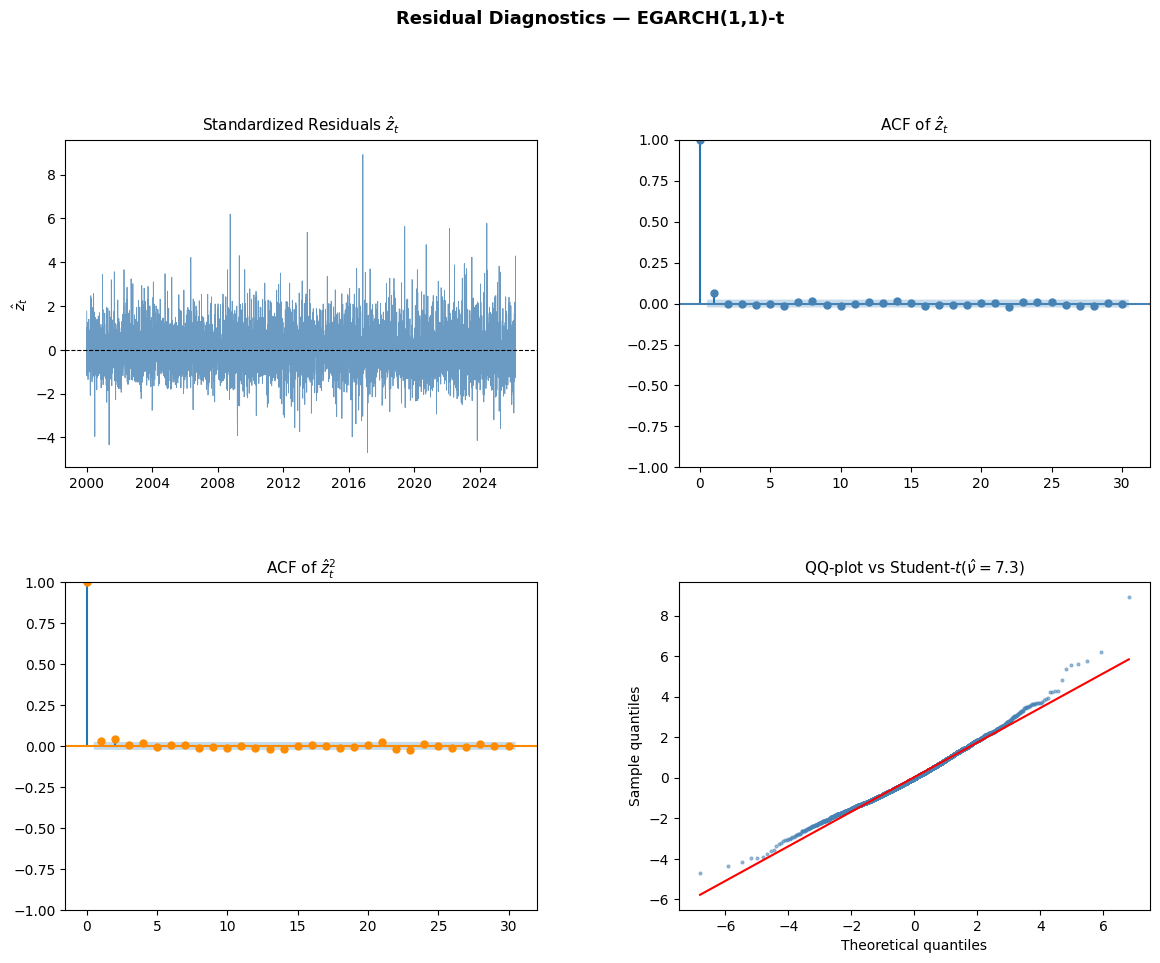

In [6]:
std_resid  = winner_model.std_resid()
winning_nu = winner_model.summary()['nu']

# ── formal tests ──────────────────────────────────────────────────────────────
lm_stat, lm_p, _, _ = het_arch(std_resid, nlags=10)
lb_z  = acorr_ljungbox(std_resid,    lags=10, return_df=True)
lb_z2 = acorr_ljungbox(std_resid**2, lags=10, return_df=True)

print(f'Residual diagnostics — {winner_name}')
print(f'  ARCH-LM (10 lags)     : LM = {lm_stat:.4f},  p = {lm_p:.4f}')
print(f'  Ljung-Box z_t  Q(10)  : stat = {lb_z["lb_stat"].iloc[-1]:.4f},  p = {lb_z["lb_pvalue"].iloc[-1]:.4f}')
print(f'  Ljung-Box z_t² Q(10)  : stat = {lb_z2["lb_stat"].iloc[-1]:.4f},  p = {lb_z2["lb_pvalue"].iloc[-1]:.4f}')
print()
print(f'  ARCH effects absorbed  : {lm_p > 0.05}')
print(f'  No remaining clustering: {lb_z2["lb_pvalue"].iloc[-1] > 0.05}')
print(f'  No autocorrelation     : {lb_z["lb_pvalue"].iloc[-1] > 0.05}')

# ── four-panel diagnostic plot ─────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)
ax1, ax2 = fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])
ax3, ax4 = fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])

# panel 1 — time series
ax1.plot(std_resid.index, std_resid.values, lw=0.6, color='steelblue', alpha=0.8)
ax1.axhline(0, color='black', lw=0.8, ls='--')
ax1.set_title('Standardized Residuals $\\hat{z}_t$', fontsize=11)
ax1.set_ylabel('$\\hat{z}_t$')

# panel 2 — ACF of residuals
plot_acf(std_resid, lags=30, alpha=0.05, ax=ax2, color='steelblue')
ax2.set_title('ACF of $\\hat{z}_t$', fontsize=11)

# panel 3 — ACF of residuals squared
plot_acf(std_resid**2, lags=30, alpha=0.05, ax=ax3, color='darkorange')
ax3.set_title('ACF of $\\hat{z}_t^2$', fontsize=11)

# panel 4 — QQ-plot vs Student-t
(osm, osr), (slope, intercept, _) = probplot(std_resid, dist=student_t, sparams=(winning_nu,))
ax4.scatter(osm, osr, s=4, color='steelblue', alpha=0.5)
ax4.plot(osm, slope * np.array(osm) + intercept, color='red', lw=1.5)
ax4.set_title(f'QQ-plot vs Student-$t$($\\hat{{\\nu}}={winning_nu:.1f}$)', fontsize=11)
ax4.set_xlabel('Theoretical quantiles')
ax4.set_ylabel('Sample quantiles')

fig.suptitle(f'Residual Diagnostics — {winner_name}', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


**What the diagnostics show:**

If ARCH-LM and Ljung-Box on $\hat{z}_t^2$ both fail to reject (p > 0.05),
the model has successfully absorbed the volatility clustering identified
in notebook 04. The standardized residuals are approximately i.i.d.

If either test still rejects, the model has not fully captured the dynamics.
This is an honest result and motivates the hybrid ML model in notebook 07:
the remaining structure in the residuals is exactly what XGBoost will
attempt to capture.

The QQ-plot tests the distributional assumption. Deviations in the tails
indicate the fitted Student-$t$ still underestimates extreme moves.


---
---
## 7. MLflow Logging

We log one run per model to MLflow via `VolatilityModel.log_to_mlflow()`.
Each run records all parameters, all metrics, and the fitted model as a
pickle artifact — a complete and reproducible record. Both models are also
saved locally to `data/processed/` for use in notebooks 06 and 07.

Run `mlflow ui --port 5001` in the terminal to inspect runs at
`http://localhost:5001`.


In [7]:
mlflow.set_tracking_uri(str(ROOT / 'mlruns'))
mlflow.set_experiment('volatility_models')

# ── log baseline manually (no VolatilityModel for the flat baseline) ──────────
with mlflow.start_run(run_name='baseline'):
    mlflow.log_param('model', 'baseline')
    mlflow.log_param('dist',  'normal')
    mlflow.log_metric('log_likelihood', log_lik_baseline)
    mlflow.log_metric('aic',            aic_baseline)
    mlflow.log_metric('bic',            bic_baseline)

# ── log GARCH and EGARCH via the class ────────────────────────────────────────
garch.log_to_mlflow(run_name='GARCH_t')
egarch.log_to_mlflow(run_name='EGARCH_t')

# ── save fitted models locally ────────────────────────────────────────────────
garch.save(ROOT  / 'data/processed/garch.pkl')
egarch.save(ROOT / 'data/processed/egarch.pkl')


MLflow: logged GARCH run "GARCH_t"
MLflow: logged EGARCH run "EGARCH_t"
Saved GARCH model → /Users/Aex/volatility_regimes/data/processed/garch.pkl
Saved EGARCH model → /Users/Aex/volatility_regimes/data/processed/egarch.pkl


---
---
## 8. Conclusion

Notebook 04 established that the Black-Scholes assumptions of constant
volatility and normally distributed returns are formally rejected for
MXN/USD log-returns. This notebook built two models that directly address
those failures.

**Key results:**

- The constant-volatility baseline is decisively rejected by both GARCH and
  EGARCH on AIC and BIC — time-varying volatility is not optional for this data.
- Persistence $\hat{\alpha} + \hat{\beta} \approx 0.987$ confirms that
  volatility shocks are long-lived: a shock today remains detectable for
  roughly 53 trading days.
- The estimated degrees of freedom $\hat{\nu} \approx 7.1$ confirms heavy
  tails. The MLE value differs from the moment-matching approximation of
  $4.6$ from notebook 04 — the full likelihood extracts more information
  than matching a single moment.
- The EGARCH asymmetry parameter $\hat{\gamma} \approx +0.07$ reveals a
  positive asymmetry specific to this currency pair: peso appreciations
  generate marginally larger volatility increases than depreciations of
  equal magnitude. This contrasts with the equity leverage effect and is
  consistent with the positive skewness ($\hat{S} = +0.78$) found in
  notebook 03.
- Residual diagnostics confirm the winning model has absorbed the ARCH
  dynamics identified in notebook 04.

**What comes next:**

Even the best GARCH-family model treats volatility regimes implicitly.
Notebook 06 fits a Hidden Markov Model (HMM) to identify discrete volatility
regimes (low / medium / high) directly, giving the hybrid model in notebook 07
an explicit regime label $z_{\text{HMM}}$ as a feature.
